# Capstone Function 8
You’re optimising an eight-dimensional black-box function, where each of the eight input parameters affects the output, but the internal mechanics are unknown. 

Your objective is to find the parameter combination that maximises the function’s output, such as performance, efficiency or validation accuracy. Because the function is high-dimensional and likely complex, global optimisation is hard, so identifying strong local maxima is often a practical strategy.

For example, imagine you’re tuning an ML model with eight hyperparameters: learning rate, batch size, number of layers, dropout rate, regularisation strength, activation function (numerically encoded), optimiser type (encoded) and initial weight range. Each input set returns a single validation accuracy score between 0 and 1. Your goal is to maximise this score.

 Input | Output | Goal |
|-------|--------|------|
| 8D Array (40, 8) | 1D Array (40, ) | Maximise |

## Initial Submission

Bayesian Optimization for 8D high-dimensional black-box function (e.g., 8 ML hyperparameters for validation accuracy).

### Step 1: Setup

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition import ExpectedImprovement
from botorch.optim import optimize_acqf
from gpytorch.mlls import ExactMarginalLogLikelihood
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
torch.manual_seed(42)
print("8D Optimization - Ready!")

/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


8D Optimization - Ready!


### Step 2: Load & Analyze Data

In [2]:
X_init = np.load('../../data/f8/updated_inputs - Week 4.npy')
y_init = np.load('../../data/f8/updated_outputs - Week 4.npy')
param_names = [f'Param_{i+1}' for i in range(8)]
print(f"8D High-Dimensional Data: {X_init.shape}")
print(f"Best accuracy/score: {y_init.max():.6f}")
print(f"Mean: {y_init.mean():.6f}, Std: {y_init.std():.6f}")

8D High-Dimensional Data: (40, 8)
Best accuracy/score: 9.598482
Mean: 7.815274, Std: 0.946903


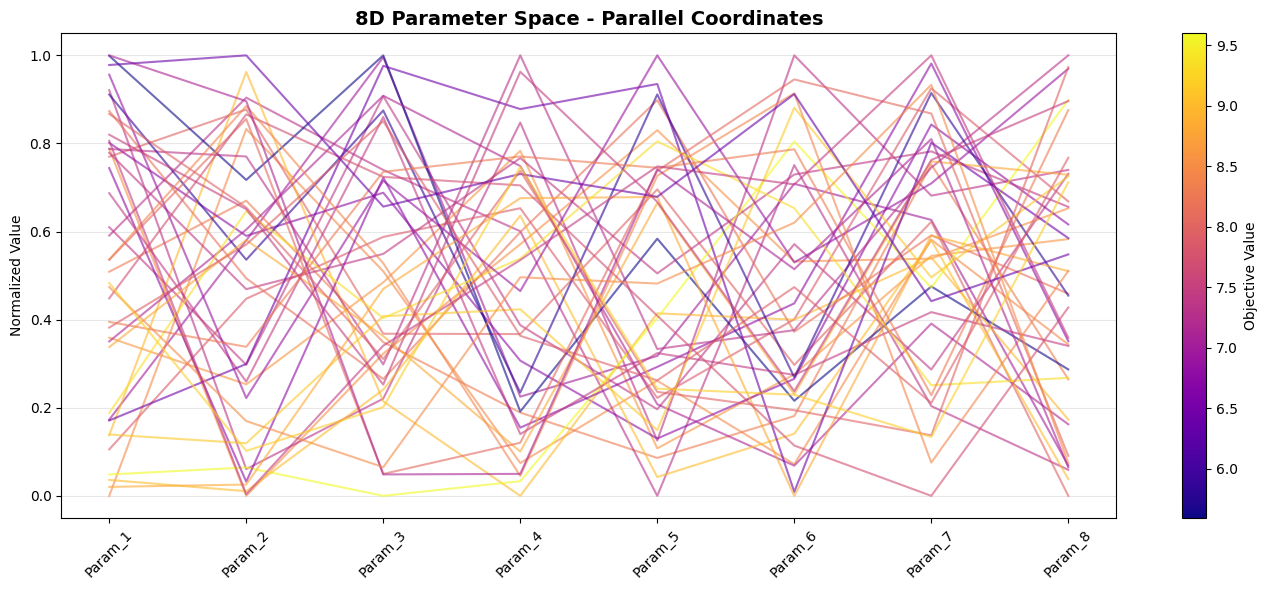

In [3]:
# Parallel coordinates plot for 8D visualization
fig, ax = plt.subplots(figsize=(14, 6))
norm = plt.Normalize(y_init.min(), y_init.max())
cmap = plt.cm.plasma
for i in range(len(X_init)):
    # Normalize each sample's features to [0, 1] for plotting
    normalized = (X_init[i] - X_init.min(axis=0)) / (X_init.max(axis=0) - X_init.min(axis=0) + 1e-8)
    ax.plot(range(8), normalized, alpha=0.6, linewidth=1.5, color=cmap(norm(y_init[i])))
ax.set_xticks(range(8))
ax.set_xticklabels(param_names, rotation=45)
ax.set_ylabel('Normalized Value')
ax.set_title('8D Parameter Space - Parallel Coordinates', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Objective Value')
plt.tight_layout()
plt.show()

### Step 3: Hyperparameters & Optimization

**8D Space Challenges:**
- High dimensionality requires more samples and restarts
- Restarts: 30, Raw: 4096 (extensive search)
- GP lengthscales reveal which dimensions matter most

In [ ]:
# All inputs must be in range [0, 0.999999] per submission requirements
N_DIM = X_init.shape[1]
BOUNDS = torch.tensor([[0.0] * N_DIM, [0.999999] * N_DIM], dtype=torch.float64)
NUM_RESTARTS, RAW_SAMPLES = 30, 4096
X_train = torch.tensor(X_init, dtype=torch.float64)
y_train = torch.tensor(y_init, dtype=torch.float64).unsqueeze(-1)
gp_model = SingleTaskGP(X_train, y_train)
mll = ExactMarginalLogLikelihood(gp_model.likelihood, gp_model)
print("Training GP on 8D space...")
fit_gpytorch_mll(mll)
print("✓ GP trained!")
EI = ExpectedImprovement(gp_model, best_f=y_train.max().item())
print("Optimizing acquisition function...")
candidate, acq_value = optimize_acqf(EI, bounds=BOUNDS, q=1, num_restarts=NUM_RESTARTS, raw_samples=RAW_SAMPLES)
next_point = candidate.detach().numpy()[0]
print(f"✓ Next 8D point: {next_point}")

Training GP on 8D space...
✓ GP trained!
Optimizing acquisition function...
✓ Next 8D point: [0.18071416 0.14111753 0.19374783 0.07186755 1.086902   0.43070208
 0.22686931 0.44425778]


### Step 4: Analysis & Visualization

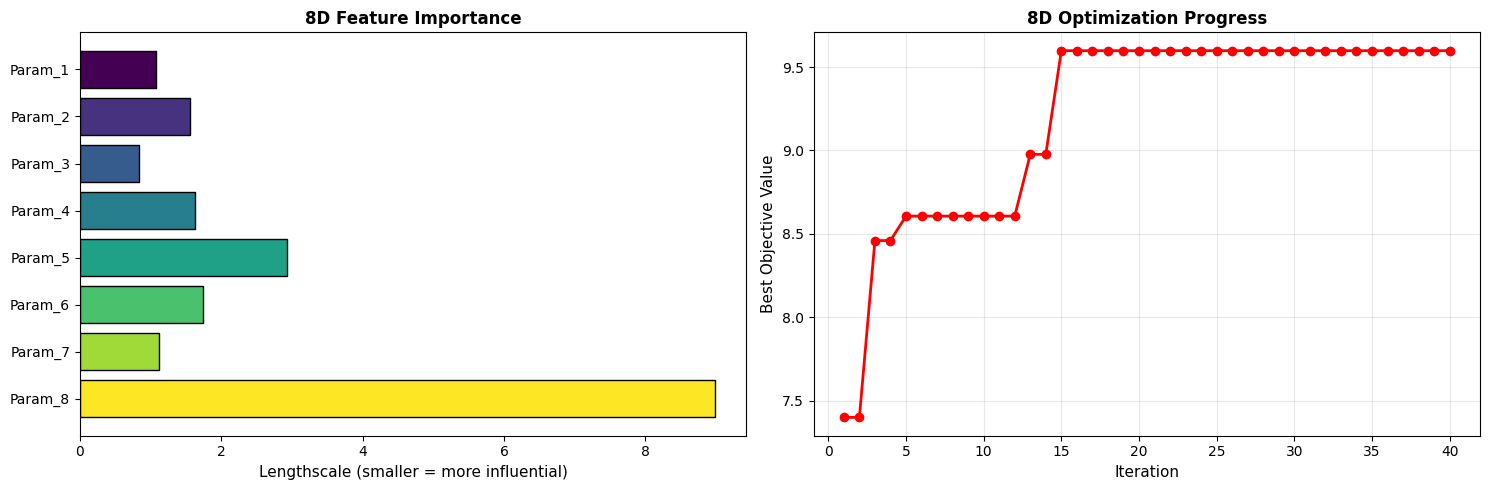


Lengthscales: [1.07529631 1.55425818 0.84212136 1.6354018  2.93585388 1.73769533
 1.11750035 8.9767361 ]
Most important param: Param_3

8D Next submission: [0.18071416 0.14111753 0.19374783 0.07186755 1.086902   0.43070208
 0.22686931 0.44425778]


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Lengthscales - feature importance (safe access for kernel structure variations)
if hasattr(gp_model.covar_module, 'base_kernel'):
    ls = gp_model.covar_module.base_kernel.lengthscale.detach().numpy()[0]
else:
    ls = gp_model.covar_module.lengthscale.detach().numpy()[0]

colors = plt.cm.viridis(np.linspace(0, 1, 8))
ax1.barh(param_names, ls, color=colors, edgecolor='black')
ax1.set_xlabel('Lengthscale (smaller = more influential)', fontsize=11)
ax1.set_title('8D Feature Importance', fontsize=12, fontweight='bold')
ax1.invert_yaxis()

# Optimization progress
best_so_far = np.maximum.accumulate(y_init)
ax2.plot(range(1, len(best_so_far)+1), best_so_far, 'r-o', linewidth=2, markersize=6)
ax2.set_xlabel('Iteration', fontsize=11)
ax2.set_ylabel('Best Objective Value', fontsize=11)
ax2.set_title('8D Optimization Progress', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nLengthscales: {ls}")
print(f"Most important param: {param_names[ls.argmin()]}")
print(f"\n8D Next submission: {next_point}")

### Visualize Expected Improvement

For higher-dimensional spaces, we visualize 1D slices of the acquisition function.
Each plot shows how EI changes along one dimension while others are fixed at the proposed point.

In [ ]:
# 1D marginal plots of Expected Improvement
n_points = 100
n_dims = len(next_point)

fig, axes = plt.subplots(1, n_dims, figsize=(4*n_dims, 4))
if n_dims == 1:
    axes = [axes]

for dim in range(n_dims):
    # Create points varying along this dimension
    X_marginal = np.tile(next_point, (n_points, 1))
    X_marginal[:, dim] = np.linspace(0, 0.999999, n_points)
    X_marginal_torch = torch.tensor(X_marginal, dtype=torch.float64)
    
    # Compute EI at each point
    with torch.no_grad():
        ei_values = EI(X_marginal_torch.unsqueeze(1)).numpy()
    
    # Plot
    axes[dim].plot(X_marginal[:, dim], ei_values, 'b-', linewidth=2)
    axes[dim].axvline(next_point[dim], color='r', linestyle='--', linewidth=2, label='Proposed')
    axes[dim].set_xlabel(f'x{dim+1}', fontsize=12)
    axes[dim].set_ylabel('Expected Improvement' if dim == 0 else '', fontsize=12)
    axes[dim].set_title(f'EI along dim {dim+1}', fontsize=11, fontweight='bold')
    axes[dim].grid(True, alpha=0.3)
    if dim == 0:
        axes[dim].legend()

plt.suptitle('Expected Improvement - 1D Marginals', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Red dashed lines show the proposed next point coordinates.")
print(f"EI is maximized when considering all dimensions jointly.")

### Step 5: Format Next Query for Submission

Format the proposed next sample point in the required submission format:
- Format: `x1-x2-x3-...-xn` where each xᵢ begins with 0
- Precision: 6 decimal places per coordinate
- Range: All values clamped to [0, 0.999999]

In [ ]:
# Format the next query for submission
def format_query(point):
    """Format point as x1-x2-...-xn with 6 decimal places, clamped to [0, 0.999999]."""
    clamped = [max(0.0, min(0.999999, x)) for x in point]
    return '-'.join([f'{x:.6f}' for x in clamped])

# Clamp next_point to valid range
next_point_clamped = np.array([max(0.0, min(0.999999, x)) for x in next_point])

# Display the formatted submission query
submission_query = format_query(next_point)
print("=" * 60)
print("SUBMISSION QUERY FOR FUNCTION 8")
print("=" * 60)
print(f"\n{submission_query}\n")
print("=" * 60)
print(f"\nCoordinates breakdown:")
for i, x in enumerate(next_point, 1):
    print(f"  x{i} = {x:.6f}")
print(f"\nEI value: {acq_value.item():.6f}")
if acq_value.item() > 0.1:
    print("  -> High EI: Strong potential for improvement")
elif acq_value.item() > 0.001:
    print("  -> Moderate EI: Some exploration potential remains")
else:
    print("  -> Low EI: Approaching convergence")
print(f"Current best observed: {y_train.max().item():.6f}")

### Summary

**8D High-Dimensional Optimization Complete**

- 40 initial samples in 8D space
- GP surrogate trained with Matern 5/2 kernel
- Expected Improvement with 30 restarts & 4096 raw samples
- Lengthscales reveal relative parameter importance
- Next point proposed for submission

**Challenges in 8D:**
- Curse of dimensionality: larger search space
- Requres more samples for good GP approximation  
- Higher computational cost for acquisition optimization
- Feature importance analysis guides future iterations